---
## This plot will create "Figure 3"(s) for the paper draft of June '26
#### now using the bootstrap & region-stratified resampling
##### 6/19/26
---

In [11]:
# kernel: pangeo23

In [2]:
# imports
import os
import xarray as xr
import numpy as np
import netCDF4 
import glob
import pandas as pd
import geopandas as gpd
from datetime import datetime
from scipy import stats

from coastal_analysis_fns import *

In [3]:
# interactive plotting stuff 
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import colors
import matplotlib.cm as cm
import matplotlib.gridspec as gridspec
from matplotlib import rcParams
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.lines import Line2D 

#import matplotlib.dates as mdates
%matplotlib inline
plt.rcParams['figure.figsize'] = 12, 6
#%config InlineBackend.figure_format = 'retina'

import cartopy
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point

In [4]:
script = 'Fig3_resubmissionJun26.ipynb'

In [5]:
# dataframe with the stations we are using
df = pd.read_csv('/home/nsiegert/projects/coastal_sst/data/hadisd_stations_using_Expanded.csv')
df = df.drop(['Unnamed: 0'], axis=1)

# convert df into geodataframe for ease of plotting
gdf = gpd.GeoDataFrame(df, geometry=gpd.points_from_xy(x=df.LON, y=df.LAT))

In [6]:
varname_outline = 'globalmean_T_X_S'
event_types = ['mhw', 'thw', 'con']
seasons = ['w', 'c']

In [7]:
## load in bootstrapped data (all of them) into a nested dictionary
# and compute global means of each quantity for each bootstrap iteration. 
varnamelist = ['sst', 'tx', 'td', 'slp', 'windspeed', 'slhf', 'sshf', 'ssr', 'str', 'slhfSTA', 'sshfSTA', 'ssrSTA', 'strSTA', 'mld']

data_in_dict = {}
globalmean_boots_dict = {}
globalmean_bootstrap50_dict = {}
globalmean_bootstrap975_dict = {}
globalmean_bootstrap025_dict = {}

for szn in ['w', 'c']:    

    # initialize empty dict's in the 'season' level (I need to do this to be able to open the data into the nested dict. this is creating the nest levels)
    for dd in [data_in_dict, globalmean_boots_dict, globalmean_bootstrap50_dict, globalmean_bootstrap975_dict, globalmean_bootstrap025_dict]:
        dd[szn] = {}

    for ev_type in ['MHW', 'THW', 'CON']:

        # initialize empty dict's in the 'event-type' level (I need to do this to be able to open the data into the nested dict. this is creating the nest levels)
        for dd in [data_in_dict, globalmean_boots_dict, globalmean_bootstrap50_dict, globalmean_bootstrap975_dict, globalmean_bootstrap025_dict]:
            dd[szn][ev_type] = {}
        
        for varname in varnamelist:

            # load in the bootstrap data (using standardized anomaly for each station) into nested dict
            da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/{}_std_{}_{}_latbinned_bootmeans.nc'.format(varname, ev_type, szn))[varname]
            data_in_dict[szn][ev_type][varname] = da

            # compute global-average quantities for each bootstrap iteration by weighting by lat area of each bin
            global_mean_bootiters_da = data_in_dict[szn][ev_type][varname].weighted(np.cos(np.deg2rad(da['lat bin']))).mean(dim='lat bin')
            globalmean_boots_dict[szn][ev_type][varname] = global_mean_bootiters_da

            # compute median, 97.5, and 02.5 %iles for the CI and stat. sig. testing. 
            globalmean_bootstrap50_dict[szn][ev_type][varname] = global_mean_bootiters_da.quantile(0.5, dim='boot')
            globalmean_bootstrap975_dict[szn][ev_type][varname] = global_mean_bootiters_da.quantile(0.975, dim='boot')
            globalmean_bootstrap025_dict[szn][ev_type][varname] = global_mean_bootiters_da.quantile(0.025, dim='boot')

In [8]:
## load in T profiles
in_Tprofile_data_dict = {}
globalmeanTprofile_boots_dict = {}
globalmean_Tprofile_bootstrap50_dict = {}
globalmean_Tprofile_bootstrap975_dict = {}
globalmean_Tprofile_bootstrap025_dict = {}

for domain in ['15deg', 'STA']:

    # initialize empty dict's in the 'season' level (I need to do this to be able to open the data into the nested dict. this is creating the nest levels)
    for dd in [in_Tprofile_data_dict, globalmeanTprofile_boots_dict, globalmean_Tprofile_bootstrap50_dict, globalmean_Tprofile_bootstrap975_dict, globalmean_Tprofile_bootstrap025_dict]:
        dd[domain] = {}

    for szn in ['w', 'c']:

        # initialize empty dict's in the 'season' level (I need to do this to be able to open the data into the nested dict. this is creating the nest levels)
        for dd in [in_Tprofile_data_dict, globalmeanTprofile_boots_dict, globalmean_Tprofile_bootstrap50_dict, globalmean_Tprofile_bootstrap975_dict, globalmean_Tprofile_bootstrap025_dict]:
            dd[domain][szn] = {}

        for ev_type in ['mhw', 'thw', 'con']:

            print(domain, szn, ev_type)
            da = xr.open_dataset('/dx02/data/nsiegert/coastal_mhw_data/{}_{}_Bootstrap_Tprofile_anom_ds_{}.nc'.format(ev_type, domain, szn)).Tx_anom
            in_Tprofile_data_dict[domain][szn][ev_type] = da

            # compute global-average quantities for each bootstrap iteration by weighting by lat area of each bin
            global_mean_Tprofile_bootiters_da = in_Tprofile_data_dict[domain][szn][ev_type].weighted(np.cos(np.deg2rad(da['lat bin']))).mean(dim='lat bin')
            globalmeanTprofile_boots_dict[domain][szn][ev_type] = global_mean_Tprofile_bootiters_da

            # compute median, 97.5, and 02.5 %iles for the CI and stat. sig. testing. 
            globalmean_Tprofile_bootstrap50_dict[domain][szn][ev_type] = global_mean_Tprofile_bootiters_da.quantile(0.5, dim='boot')
            globalmean_Tprofile_bootstrap975_dict[domain][szn][ev_type] = global_mean_Tprofile_bootiters_da.quantile(0.975, dim='boot')
            globalmean_Tprofile_bootstrap025_dict[domain][szn][ev_type] = global_mean_Tprofile_bootiters_da.quantile(0.025, dim='boot')


# save pressure levels
plevels = da.level

15deg w mhw
15deg w thw
15deg w con
15deg c mhw
15deg c thw
15deg c con
STA w mhw
STA w thw
STA w con
STA c mhw
STA c thw
STA c con


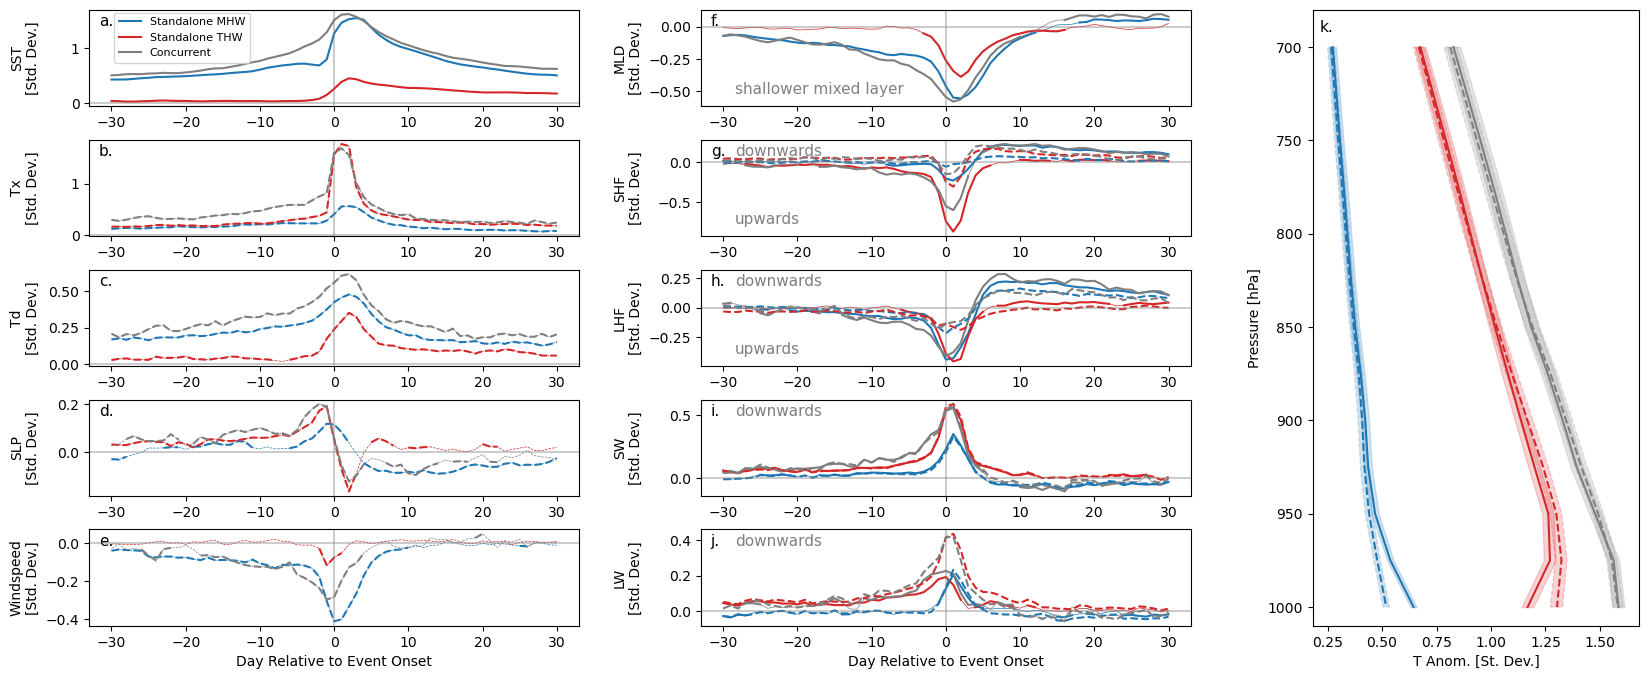

In [10]:
### full figure, with new bootstrapped T profiles plus other CI stuff. 


# set up figure
nrows = 5
ncols = 3
fig = plt.figure(figsize=(20, 8))
gs = gridspec.GridSpec(nrows=nrows, ncols=ncols, figure=fig, width_ratios=[1.5, 1.5, 1]) 
gs.update(wspace=0.28, hspace=0.35)


## loop thru and plot variable progressions
row_label_list = ['SST', 'Tx', 'Td', 'SLP', 'Windspeed', 'MLD', 'SHF', 'LHF', 'SW', 'LW']
letters = ['a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k']

pltctr = 0
r = 0
c = 0

axes = []

for pltctr, varname in enumerate(['sst', 'tx', 'td', 'slp', 'windspeed', 'mld', 'sshf', 'slhf', 'ssr', 'str']):
    
    # add ax
    ax = fig.add_subplot(gs[r, c])        
    
    # set linestyle (using dashes for measurements taken over station, solid line for over ocean)
    if pltctr in [1, 2, 3, 4]:
        lls = '--'
    else:
        lls = '-'

    # plot stuff - pick the data to plot, and plot the data
    for ev_type in ['MHW', 'THW', 'CON']:

        if ev_type=='MHW':
            lab = 'Standalone MHW'
            clr = 'tab:blue'
        elif ev_type=='THW':
            lab = 'Standalone THW'
            clr = 'tab:red'
        elif ev_type=='CON':
            lab = 'Concurrent'
            clr = 'tab:grey'

        # select data
        mean2plot = globalmean_bootstrap50_dict['w'][ev_type][varname]

        # select areas where the <var> is sig. different from 0
        sig_mask = np.logical_not((globalmean_bootstrap025_dict['w'][ev_type][varname] < 0) * (globalmean_bootstrap975_dict['w'][ev_type][varname] > 0))
        
        # plot the data 
        mean2plot.plot(ax=ax, color=clr, ls=lls, lw=0.5) # first plot everything, even where not stat-sig using thin line
        mean2plot.where(sig_mask).plot(ax=ax, label=lab, color=clr, ls=lls) # then plot stat-sig stuff on top using thick line

    
    # for the heatfluxes, also plot the over-station data:
    if pltctr>5:    

        for ev_type in ['MHW', 'THW', 'CON']:

            if ev_type=='MHW':
                clr = 'tab:blue'
            elif ev_type=='THW':
                clr = 'tab:red'
            elif ev_type=='CON':
                clr = 'tab:grey'
        
            mean2plotSTA = globalmean_bootstrap50_dict['w'][ev_type][varname+'STA']

            # plot the over-station data
            mean2plotSTA.plot(ax=ax, color=clr, ls='--')

        # add axis text
        ax.text(s='downwards', x=0.07, y=0.83, transform=ax.transAxes, ha='left', fontsize=11, color='grey')

        
    # axis cosmetics
    ax.set(xlabel='', ylabel='{}\n[Std. Dev.]'.format(row_label_list[pltctr]), title='') # for now
    ax.axvline(color='grey', alpha=0.4)
    ax.text(s='{}.'.format(letters[pltctr]), x=0.02, y=0.83, transform=ax.transAxes, ha='left', fontsize=11)
    ax.axhline(color='grey', alpha=0.4)
    
    # if it's the first plot, I want to save the legend elements
    handles1, labels1 = ax.get_legend_handles_labels()
    
    # update plot counter, row and column at the end of this list
    axes.append(ax)
    pltctr += 1
    r += 1
    
    if r==nrows:
        r = 0
        c += 1
    
# axis legends, labels, descriptive text
axes[0].legend(loc=(0.051, 0.45), fontsize=8)
axes[4].set(xlabel='Day Relative to Event Onset')
axes[9].set(xlabel='Day Relative to Event Onset')   
axes[5].text(s='shallower mixed layer', x=0.07, y=0.13, transform=axes[5].transAxes, ha='left', fontsize=11, color='grey')
axes[6].text(s='upwards', x=0.07, y=0.13, transform=axes[6].transAxes, ha='left', fontsize=11, color='grey')
axes[7].text(s='upwards', x=0.07, y=0.13, transform=axes[7].transAxes, ha='left', fontsize=11, color='grey')

    
## T-Profile axis
ax = fig.add_subplot(gs[:, 2])

for ev_type in event_types:
    
    if ev_type == 'mhw':
        cc = 'tab:blue'
    elif ev_type == 'thw':
        cc = 'tab:red'
    elif ev_type == 'con':
        cc = 'grey'
        
    vname1 = 'globalmean_T_{}_w'.format(ev_type)
    vname2 = 'globalmean_T_STA_{}_w'.format(ev_type)
    
    ax.plot(globalmean_Tprofile_bootstrap50_dict['15deg']['w'][ev_type], plevels, color=cc, ls='-') # plot T profile for that event over ocean
    ax.fill_betweenx(y=plevels, x1=globalmean_Tprofile_bootstrap025_dict['15deg']['w'][ev_type], 
                     x2=globalmean_Tprofile_bootstrap975_dict['15deg']['w'][ev_type], color=cc, alpha=0.2) 

    ax.plot(globalmean_Tprofile_bootstrap50_dict['STA']['w'][ev_type], plevels, color=cc, ls='--') # plot T profile for that event over station
    ax.fill_betweenx(y=plevels, x1=globalmean_Tprofile_bootstrap025_dict['STA']['w'][ev_type], 
                     x2=globalmean_Tprofile_bootstrap975_dict['STA']['w'][ev_type], color=cc, alpha=0.2, ls='--') # warm-season CI

    
    ax.invert_yaxis()
    
# cosmetics (axis labels, letter to ID subplot, shift ax lim down a bit so letter doesn't overlap data)
ax.set(ylabel='Pressure [hPa]', xlabel='T Anom. [St. Dev.]')
ax.text(s='k.', x=0.02, y=0.965, transform=ax.transAxes, ha='left', fontsize=11)
ax.set_ylim(1010.0, 680.0)


# Align the y-labels
fig.align_ylabels(axes) # You can pass a specific list of axes or leave empty to align all

# time & script
# now = datetime.now() # get datetime
# fig.text(0.85, 0.015, 'Created: %s' %now.strftime("%Y-%m-%d %H:%M:%S"), fontsize='x-small', ha='right') # text
# fig.text(0.85, 0.005, script, ha='right', fontsize='x-small')

# SAVE FIGURE
plt.savefig('/home/nsiegert/projects/coastal_sst/plots/grl_resubmission_6.2026/Fig3_coastalsst_grl_6_26.png', format='png', bbox_inches='tight')

plt.show()